# LLM Judge Error Category Distribution

This notebook loads judge score CSVs and plots error `category` distributions per setting.

In [2]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('default')
pd.set_option('display.max_colwidth', 200)


In [3]:
SCORES_DIR = Path('scores')
score_paths = sorted(SCORES_DIR.glob('*__judge-*.csv'))
print(f'Found {len(score_paths)} score files in {SCORES_DIR.resolve()}')
for p in score_paths:
    print('-', p.name)


Found 12 score files in /Users/mariateleki/Desktop/Uh-Mazing/llm-as-a-judge/scores
- uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv
- uh-mazing_gemini-2.5-flash_audio_standard-noextra__judge-gpt-5.2-2025-12-11.csv
- uh-mazing_gemini-2.5-flash_text_disfluent_disfluent__judge-gpt-5.2-2025-12-11.csv
- uh-mazing_gemini-2.5-flash_text_disfluent_fluent__judge-gpt-5.2-2025-12-11.csv
- uh-mazing_gemini-2.5-flash_text_standard_disfluent__judge-gpt-5.2-2025-12-11.csv
- uh-mazing_gemini-2.5-flash_text_standard_fluent__judge-gpt-5.2-2025-12-11.csv
- uh-mazing_gpt52_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv
- uh-mazing_gpt52_audio_standard-noextra__judge-gpt-5.2-2025-12-11.csv
- uh-mazing_gpt52_text_disfluent_disfluent__judge-gpt-5.2-2025-12-11.csv
- uh-mazing_gpt52_text_disfluent_fluent__judge-gpt-5.2-2025-12-11.csv
- uh-mazing_gpt52_text_standard_disfluent__judge-gpt-5.2-2025-12-11.csv
- uh-mazing_gpt52_text_standard_fluent__judge-gpt-5.2-2025-12-11.c

In [4]:
def parse_file_meta(filename: str) -> tuple[str, str]:
    # Expected: uh-mazing_<model>_<setting>__judge-<judge_model>.csv
    m = re.match(r'^uh-mazing_(.+?)_(audio_[^_]+-noextra|text_[^_]+_[^_]+)__judge-.+\.csv$', filename)
    if not m:
        return ('unknown_model', 'unknown_setting')
    return m.group(1), m.group(2)


def parse_error_json(value):
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    try:
        parsed = json.loads(text)
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return []


rows = []

for path in score_paths:
    model, setting = parse_file_meta(path.name)
    df = pd.read_csv(path)
    err_cols = [c for c in df.columns if c.endswith('__judge_errors_json')]

    for err_col in err_cols:
        lang = err_col.split('_', 1)[0]
        for row_idx, raw in enumerate(df[err_col]):
            errors = parse_error_json(raw)
            for e in errors:
                if not isinstance(e, dict):
                    continue
                category = str(e.get('category', '')).strip()
                if not category:
                    continue
                rows.append({
                    'file': path.name,
                    'model': model,
                    'setting': setting,
                    'lang': lang,
                    'row_idx': row_idx,
                    'category': category,
                })

errors_df = pd.DataFrame(rows)
print('Extracted error annotations:', len(errors_df))
errors_df.head()


Extracted error annotations: 30087


,file,model,setting,lang,row_idx,category
0,uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv,gemini-2.5-flash,audio_disfluent-noextra,ZH,0,Disfluency > Deletion
1,uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv,gemini-2.5-flash,audio_disfluent-noextra,ZH,0,Meaning Preservation
2,uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv,gemini-2.5-flash,audio_disfluent-noextra,ZH,1,General > Missing content
3,uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv,gemini-2.5-flash,audio_disfluent-noextra,ZH,1,Disfluency > Deletion
4,uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv,gemini-2.5-flash,audio_disfluent-noextra,ZH,2,Disfluency > Extra


In [5]:
if errors_df.empty:
    raise ValueError('No error categories found. Check score files and __judge_errors_json columns.')

errors_df['model_setting'] = errors_df['model'] + ' | ' + errors_df['setting']

summary = (
    errors_df.groupby(['model_setting', 'category'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values(['model_setting', 'count'], ascending=[True, False])
)
summary.head(30)


,model_setting,category,count
0,gemini-2.5-flash | audio_disfluent-noextra,Disfluency > Deletion,487
7,gemini-2.5-flash | audio_disfluent-noextra,General > Missing content,466
2,gemini-2.5-flash | audio_disfluent-noextra,Disfluency > Type mismatch,461
4,gemini-2.5-flash | audio_disfluent-noextra,General > Incorrect language,233
1,gemini-2.5-flash | audio_disfluent-noextra,Disfluency > Extra,205
3,gemini-2.5-flash | audio_disfluent-noextra,General > Extra content,86
11,gemini-2.5-flash | audio_disfluent-noextra,Meaning Preservation,36
9,gemini-2.5-flash | audio_disfluent-noextra,Meaning > Incorrect language,15
6,gemini-2.5-flash | audio_disfluent-noextra,General > Meaning distortion,10
12,gemini-2.5-flash | audio_disfluent-noextra,Meaning Preservation > Incorrect language,10


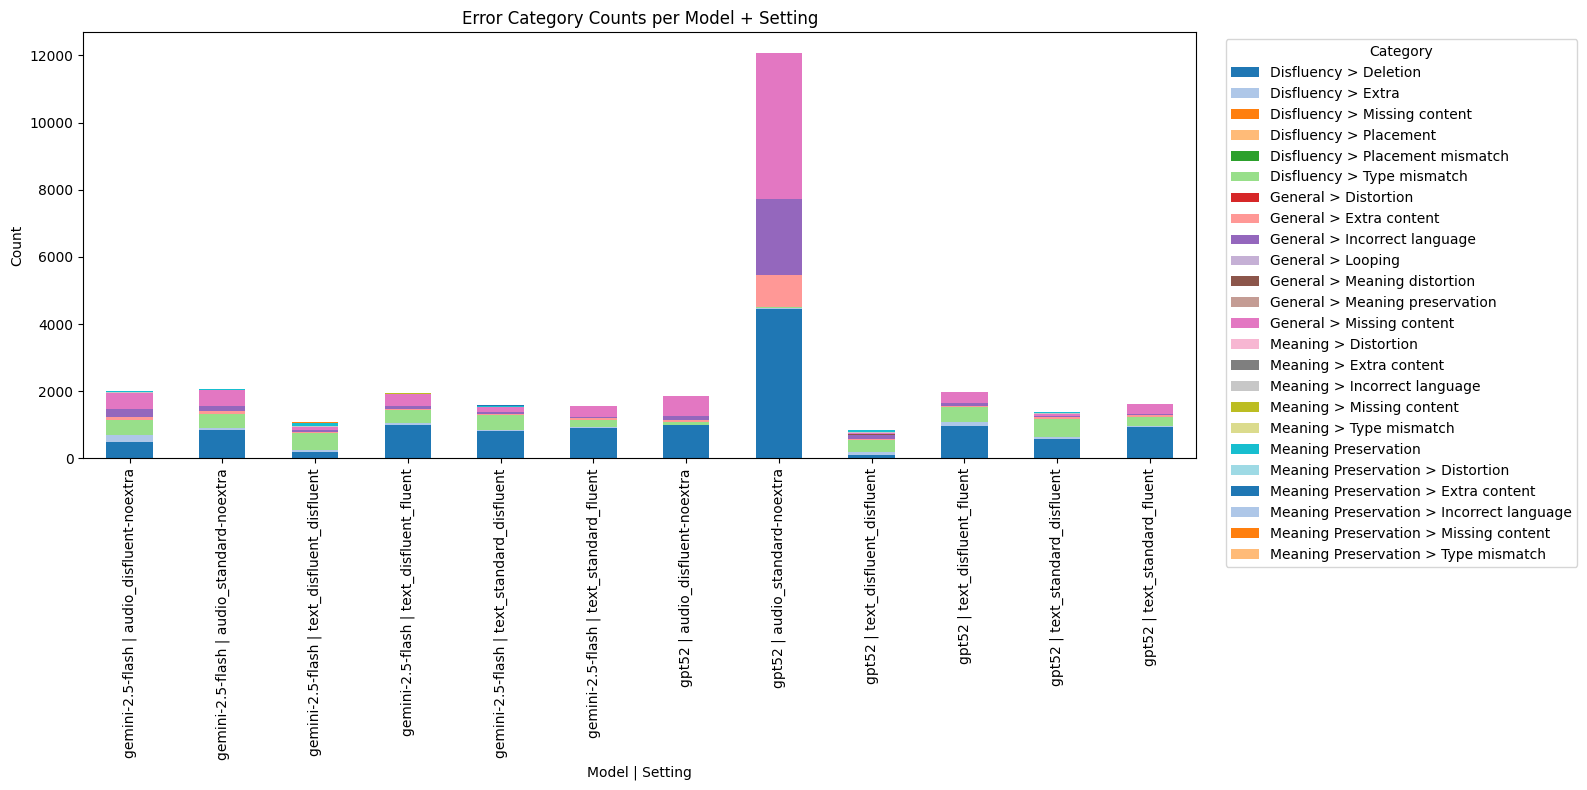

In [6]:
pivot_counts_raw = (
    errors_df.groupby(['model_setting', 'category'])
    .size()
    .unstack(fill_value=0)
)

# Fixed global category order for stable legends/colors across all plots.
category_order = sorted([c for c in pivot_counts_raw.columns if pivot_counts_raw[c].sum() > 0])
pivot_counts = pivot_counts_raw.reindex(columns=category_order, fill_value=0)

cmap = plt.get_cmap('tab20')
category_colors = {cat: cmap(i % cmap.N) for i, cat in enumerate(category_order)}
plot_colors = [category_colors[c] for c in category_order]

ax = pivot_counts.plot(kind='bar', stacked=True, figsize=(16, 8), color=plot_colors)
ax.set_title('Error Category Counts per Model + Setting')
ax.set_xlabel('Model | Setting')
ax.set_ylabel('Count')
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


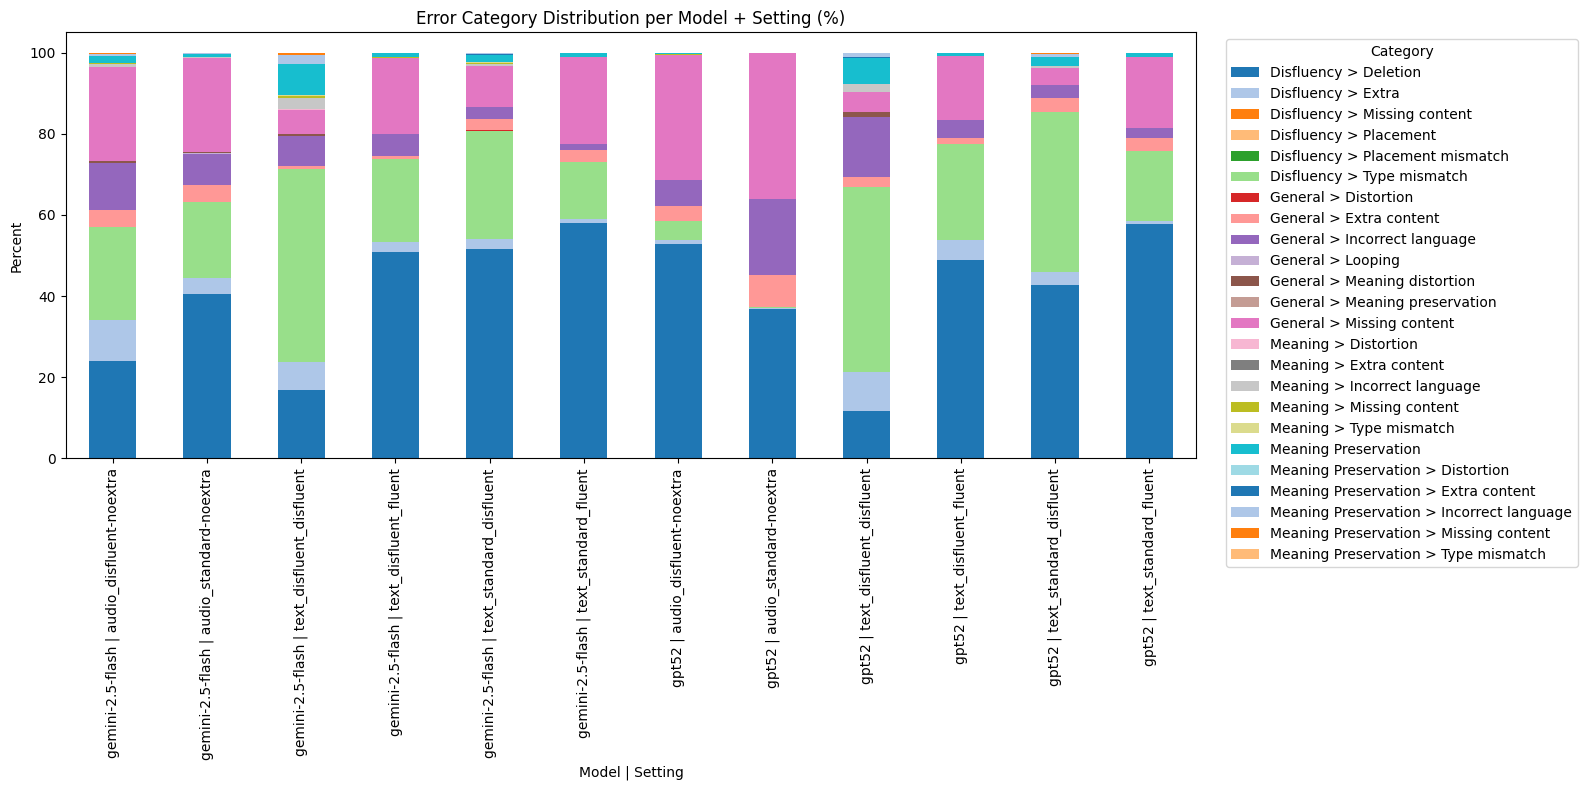

In [7]:
pivot_pct = pivot_counts.div(pivot_counts.sum(axis=1), axis=0).fillna(0) * 100

ax = pivot_pct.plot(kind='bar', stacked=True, figsize=(16, 8), color=plot_colors)
ax.set_title('Error Category Distribution per Model + Setting (%)')
ax.set_xlabel('Model | Setting')
ax.set_ylabel('Percent')
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [8]:
top_categories = (
    summary.sort_values(['model_setting', 'count'], ascending=[True, False])
    .groupby('model_setting')
    .head(5)
)
top_categories


,model_setting,category,count
0,gemini-2.5-flash | audio_disfluent-noextra,Disfluency > Deletion,487
7,gemini-2.5-flash | audio_disfluent-noextra,General > Missing content,466
2,gemini-2.5-flash | audio_disfluent-noextra,Disfluency > Type mismatch,461
4,gemini-2.5-flash | audio_disfluent-noextra,General > Incorrect language,233
1,gemini-2.5-flash | audio_disfluent-noextra,Disfluency > Extra,205
14,gemini-2.5-flash | audio_standard-noextra,Disfluency > Deletion,840
21,gemini-2.5-flash | audio_standard-noextra,General > Missing content,484
16,gemini-2.5-flash | audio_standard-noextra,Disfluency > Type mismatch,388
18,gemini-2.5-flash | audio_standard-noextra,General > Incorrect language,158
17,gemini-2.5-flash | audio_standard-noextra,General > Extra content,90


In [9]:
score_rows = []

for path in score_paths:
    model, setting = parse_file_meta(path.name)
    df = pd.read_csv(path)

    style_cols = [c for c in df.columns if c.endswith('__judge_style_preservation_score')]
    for style_col in style_cols:
        base = style_col.removesuffix('__judge_style_preservation_score')
        meaning_col = f'{base}__judge_meaning_preservation_score'
        lang = base.split('_', 1)[0]

        if meaning_col not in df.columns:
            continue

        for row_idx, (style, meaning) in enumerate(zip(df[style_col], df[meaning_col])):
            style_num = pd.to_numeric(style, errors='coerce')
            meaning_num = pd.to_numeric(meaning, errors='coerce')
            if pd.isna(style_num) or pd.isna(meaning_num):
                continue
            score_rows.append({
                'file': path.name,
                'model': model,
                'setting': setting,
                'lang': lang,
                'row_idx': row_idx,
                'style_score': float(style_num),
                'meaning_score': float(meaning_num),
            })

scores_df = pd.DataFrame(score_rows)
print('Extracted score pairs:', len(scores_df))
scores_df.head()


Extracted score pairs: 13304


,file,model,setting,lang,row_idx,style_score,meaning_score
0,uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv,gemini-2.5-flash,audio_disfluent-noextra,ZH,0,88.0,86.0
1,uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv,gemini-2.5-flash,audio_disfluent-noextra,ZH,1,78.0,92.0
2,uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv,gemini-2.5-flash,audio_disfluent-noextra,ZH,2,78.0,86.0
3,uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv,gemini-2.5-flash,audio_disfluent-noextra,ZH,3,78.0,82.0
4,uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv,gemini-2.5-flash,audio_disfluent-noextra,ZH,4,92.0,98.0


/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_40771/2688302246.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(style_groups, labels=style_labels, showfliers=False)
/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_40771/2688302246.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(meaning_groups, labels=meaning_labels, showfliers=False)


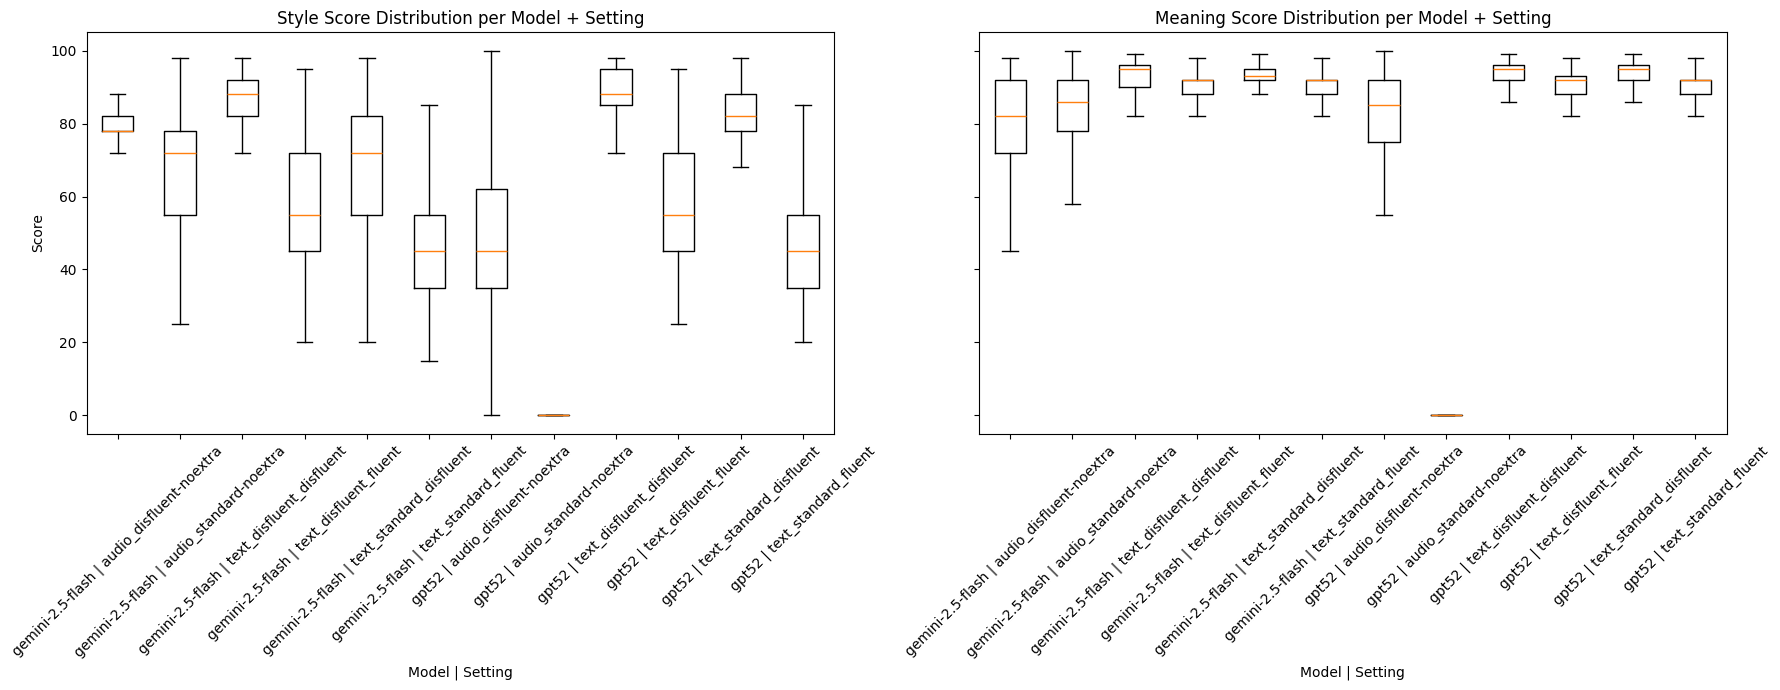

In [10]:
if scores_df.empty:
    raise ValueError('No style/meaning scores found in score files.')

scores_df['model_setting'] = scores_df['model'] + ' | ' + scores_df['setting']

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

style_groups = [grp['style_score'].values for _, grp in scores_df.groupby('model_setting')]
style_labels = [name for name, _ in scores_df.groupby('model_setting')]
axes[0].boxplot(style_groups, labels=style_labels, showfliers=False)
axes[0].set_title('Style Score Distribution per Model + Setting')
axes[0].set_xlabel('Model | Setting')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=45)

meaning_groups = [grp['meaning_score'].values for _, grp in scores_df.groupby('model_setting')]
meaning_labels = [name for name, _ in scores_df.groupby('model_setting')]
axes[1].boxplot(meaning_groups, labels=meaning_labels, showfliers=False)
axes[1].set_title('Meaning Score Distribution per Model + Setting')
axes[1].set_xlabel('Model | Setting')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


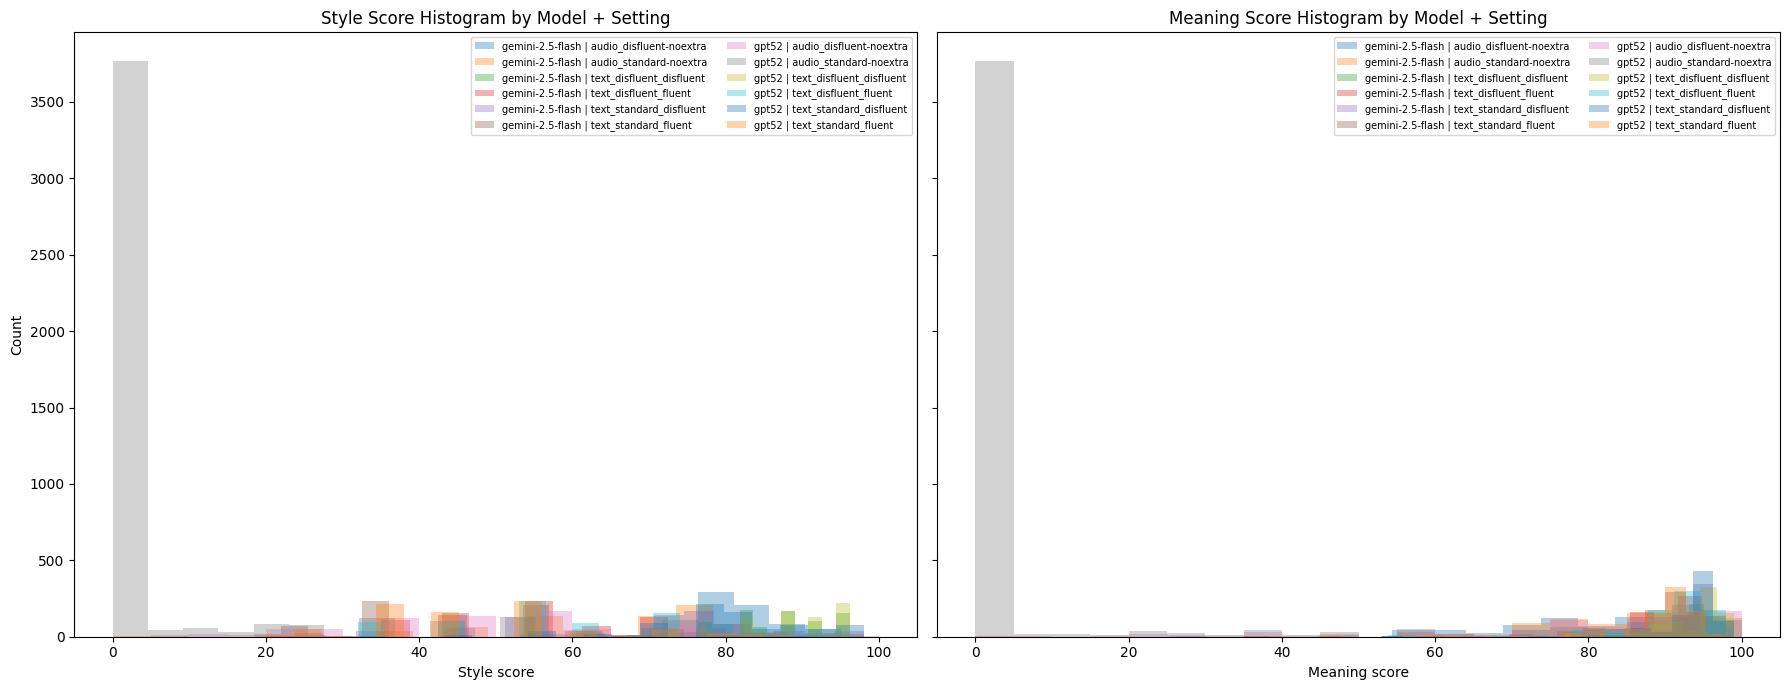

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for model_setting, grp in scores_df.groupby('model_setting'):
    axes[0].hist(grp['style_score'], bins=20, alpha=0.35, label=model_setting)
    axes[1].hist(grp['meaning_score'], bins=20, alpha=0.35, label=model_setting)

axes[0].set_title('Style Score Histogram by Model + Setting')
axes[0].set_xlabel('Style score')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_title('Meaning Score Histogram by Model + Setting')
axes[1].set_xlabel('Meaning score')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()


In [12]:
summary_scores = (
    scores_df.groupby(['model', 'setting'])[['style_score', 'meaning_score']]
    .agg(['mean', 'median', 'std'])
    .round(2)
)
summary_scores


style_score                \
                                                 mean median    std   
model            setting                                              
gemini-2.5-flash audio_disfluent-noextra        79.20   78.0   7.69   
                 audio_standard-noextra         67.19   72.0  16.53   
                 text_disfluent_disfluent       86.95   88.0   5.95   
                 text_disfluent_fluent          55.26   55.0  14.54   
                 text_standard_disfluent        69.76   72.0  16.34   
                 text_standard_fluent           45.62   45.0  13.86   
gpt52            audio_disfluent-noextra        48.92   45.0  20.08   
                 audio_standard-noextra          6.48    0.0  16.80   
                 text_disfluent_disfluent       88.86   88.0   5.95   
                 text_disfluent_fluent          58.24   55.0  13.97   
                 text_standard_disfluent        79.87   82.0  10.82   
                 text_standard_fluent           47.52   45.0  13.94   

                                          meaning_score                
                                                   mean median    std  
model            setting                                               
gemini-2.5-flash audio_disfluent-noextra          81.06   82.0  13.45  
                 audio_standard-noextra           82.23   86.0  14.26  
                 text_disfluent_disfluent         92.47   95.0   5.41  
                 text_disfluent_fluent            88.48   92.0   7.24  
                 text_standard_disfluent          92.06   93.0   5.31  
                 text_standard_fluent             89.53   92.0   6.28  
gpt52            audio_disfluent-noextra          78.95   85.0  20.46  
                 audio_standard-noextra           11.24    0.0  27.63  
                 text_disfluent_disfluent         92.83   95.0   5.82  
                 text_disfluent_fluent            89.29   92.0   7.36  
                 text_standard_disfluent          93.46   95.0   4.66  
                 text_standard_fluent             89.92   92.0   6.46

In [18]:
# Example browser: show source/target samples for a selected error category
CATEGORY_TO_SHOW = 'General > Extra content'  # e.g., 'Disfluency > Extra'
LANG_TO_SHOW = None  # e.g., 'ES', 'ZH', 'HI'; keep None for all languages
RANDOM_SEED = 42

def clean_source_text(text):
    text = str(text)
    text = text.replace('_', '').replace(' ,', ',').replace(' .', '.').replace(" '", "'")
    return re.sub(r'\s+', ' ', text).strip()

sample_rows = []

for path in score_paths:
    model, setting = parse_file_meta(path.name)
    df = pd.read_csv(path)

    if 'EN_disfluent' not in df.columns:
        continue

    err_cols = [c for c in df.columns if c.endswith('__judge_errors_json')]

    for err_col in err_cols:
        target_col = err_col.removesuffix('__judge_errors_json')
        lang = target_col.split('_', 1)[0]

        if LANG_TO_SHOW is not None and str(lang).upper() != str(LANG_TO_SHOW).upper():
            continue

        if target_col not in df.columns:
            continue

        for row_idx, raw in enumerate(df[err_col]):
            errs = parse_error_json(raw)
            matched = [e for e in errs if isinstance(e, dict) and str(e.get('category', '')).strip() == CATEGORY_TO_SHOW]
            if not matched:
                continue

            source = clean_source_text(df.at[row_idx, 'EN_disfluent'])
            target = str(df.at[row_idx, target_col]) if not pd.isna(df.at[row_idx, target_col]) else ''
            descriptions = ' | '.join(str(e.get('description', '')).strip() for e in matched if str(e.get('description', '')).strip())

            sample_rows.append({
                'file': path.name,
                'model': model,
                'setting': setting,
                'lang': lang,
                'row_idx': row_idx,
                'id': str(df.at[row_idx, 'ID']) if 'ID' in df.columns else '',
                'category': CATEGORY_TO_SHOW,
                'description': descriptions,
                'source': source,
                'target': target,
            })

samples_df = pd.DataFrame(sample_rows)

print(f'Matches for {CATEGORY_TO_SHOW!r}' + (f' in {LANG_TO_SHOW!r}' if LANG_TO_SHOW else '') + f': {len(samples_df)}')
if samples_df.empty:
    print('No matching samples found.')
else:
    shown_df = samples_df.sample(frac=1, random_state=RANDOM_SEED)
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
        display(shown_df)


Matches for 'General > Extra content': 1454


,file,model,setting,lang,row_idx,category,description,source,target
70,uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv,gemini-2.5-flash,audio_disfluent-noextra,AR,9,General > Extra content,"The target adds ""قد"" (already/indeed) which is not present in the source.","So, so, I mean, it, I mean, I, I, I, I har-, I, I truly wish that if something like that were to happen that my children would do something like, that for me.",فـ، فـ، أعني، أعني أنا أنا قد أنا أنا هارت أنا أتمنى حقًا لو حدث شيء كهذا، أن يفعل أطفالي شيئًا كهذا من أجلي.
71,uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv,gemini-2.5-flash,audio_disfluent-noextra,AR,31,General > Extra content,"The target adds ""نعم"" before ""هذا تخمين"" which is not explicitly present in the source.","Well, presumably those who find out such information, if they are doing it, I would prefer to not to be known, and, I mean, you know, the classic, oh, I do n't know C I A conspiracy theories or wh...",حسناً، من المفترض أن أولئك الذين يكتشفون مثل هذه المعلومات، إذا كانوا يفعلون ذلك، أفضل ألا يُعرفوا وأعني، كما تعلم، نظريات المؤامرة الكلاسيكية، أوه، لا أعرف، وكالة المخابرات المركزية أو أياً كان، ...
72,uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv,gemini-2.5-flash,audio_disfluent-noextra,AR,36,General > Extra content,"The translation begins with ""لأجلها."" which has no clear counterpart in the source.","I mean, you know, you can't tell it, what a company really has to do with it and there's something rather ominous about having virtually anyone, any hacker being able to know what your income is, ...",لأجلها. أعني، تعلم، لا يمكنك معرفة ما ما علاقة الشركة حقًا بذلك وهناك شيء ينذر بالسوء إلى حد ما بشأن وجود أي شخص تقريبًا، أي متسلل قادر على معرفة ما هو دخلك، وما هي عادات إنفاقك، و، تعلم، و وهذا ا...
73,uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv,gemini-2.5-flash,audio_disfluent-noextra,AR,38,General > Extra content,"Target begins with ""وحده."" which has no counterpart in the source.","Whereas in this country where everyone respects the closed doors very much, if you go out and then act like the lunatic you, you violate the, uh, the norms of social, of, um, public behavior. Um, ...",وحده. بينما في هذا البلد حيث يحترم الجميع الأبواب المغلقة كثيرًا، إذا خرجت وتصرفت كالبدو، أنت أنت تنتهك الـ اه الـ معايير السلوكية الاجتماعية الـ امم العامة. امم، الناس يبدأون بالانتباه إليك كثيرً...
75,uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv,gemini-2.5-flash,audio_disfluent-noextra,AR,53,General > Extra content,"The translation starts with ""قديم جداً"" (very old), which is not present in the source.","I mean I, I, there are a lot, there are so many different songs, I mean like the whole thing about cover versions a lot of times. I mean I've heard some songs that, that I just thought were horren...",قديم جداً. أعني، أنا أنا هناك الكثير الكثير من الأغاني المختلفة. أعني، مثل كل شيء عن نسخ الكفر (cover versions) في كثير من الأحيان. أعني، لقد سمعت بعض الأغاني التي التي اعتقدت أنها نسخ كفر (cover ...
...,...,...,...,...,...,...,...,...,...
1402,uh-mazing_gpt52_text_standard_fluent__judge-gpt-5.2-2025-12-11.csv,gpt52,text_standard_fluent,ZH,4,General > Extra content,"Target adds ""被确诊"" (diagnosed), which is not explicitly stated in the source (it only says she had Parkinson's disease).","Uh-huh. Yeah. Probably the hardest thing in, in my family, uh, my grandmother, she had to be put in a nursing home and, um, she had used the walker for, for quite some time, probably about six to ...",在我家里，可能最难的一件事就是我奶奶的情况。她不得不被送进养老院，而且她用助行器已经有一段时间了，大概六到九个月。后来她摔了一跤，最终被确诊患有帕金森病。
1403,uh-mazing_gpt52_text_standard_fluent__judge-gpt-5.2-2025-12-11.csv,gpt52,text_standard_fluent,ZH,42,General > Extra content,译文加入了源语未明确表达的内容与细化：如“在楼里到处走”“转悠”“适合一家人活动的时间”等，对“walk around”“family hours”的解释更具体，带来轻微增译。,"Uh-huh, uh-huh. Yeah, that's true. Living in an apartment complex


[70] model=gemini-2.5-flash | setting=audio_disfluent-noextra | lang=AR | row=9 | uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv
file: uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv
description: The target adds "قد" (already/indeed) which is not present in the source.
SOURCE: So, so, I mean, it, I mean, I, I, I, I har-, I, I truly wish that if something like that were to happen that my children would do something like, that for me.
TARGET: فـ، فـ، أعني، أعني أنا أنا قد أنا أنا هارت أنا أتمنى حقًا لو حدث شيء كهذا، أن يفعل أطفالي شيئًا كهذا من أجلي.

[71] model=gemini-2.5-flash | setting=audio_disfluent-noextra | lang=AR | row=31 | uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv
file: uh-mazing_gemini-2.5-flash_audio_disfluent-noextra__judge-gpt-5.2-2025-12-11.csv
description: The target adds "نعم" before "هذا تخمين" which is not explicitly present in the source.
SOURCE: Well, presumably